In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
math_df = pd.read_csv("student-mat.csv", sep=";")

In [3]:
math_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [4]:
pd.set_option('display.max_columns', None)


In [8]:
math_df.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10


In [9]:
math_df.tail(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,course,father,1,1,0,no,no,no,no,yes,yes,yes,no,3,2,3,3,3,5,5,8,9,9


1. Does study time affect final grades? studytime, G3 - Boxplot - ANOVA

In [11]:
math_df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [12]:
math_df.studytime.unique()

array([2, 3, 1, 4])

In [14]:
math_df.studytime.value_counts()

studytime
2    198
1    105
3     65
4     27
Name: count, dtype: int64

In [21]:
math_df.G3.unique()

array([ 6, 10, 15, 11, 19,  9, 12, 14, 16,  5,  8, 17, 18, 13, 20,  7,  0,
        4])

In [24]:
math_df.G3.value_counts()

G3
10    56
11    47
0     38
15    33
8     32
12    31
13    31
9     28
14    27
16    16
6     15
18    12
7      9
5      7
17     6
19     5
20     1
4      1
Name: count, dtype: int64

<Axes: xlabel='studytime', ylabel='G3'>

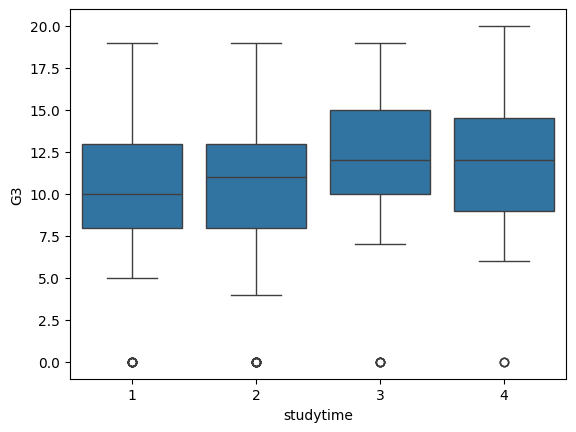

In [25]:
sns.boxplot(x="studytime", y="G3", data=math_df)

In [27]:
math_df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [36]:
from scipy.stats import f_oneway

# Divide G3 into groups according to studytime
group1 = math_df[math_df['studytime'] == 1]['G3']
group2 = math_df[math_df['studytime'] == 2]['G3']
group3 = math_df[math_df['studytime'] == 3]['G3']
group4 = math_df[math_df['studytime'] == 4]['G3']

# Perform one-way ANOVA
f_stat, p_value = f_oneway(group1, group2, group3, group4)

print(f"F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1.7278351054436039
p-value: 0.1607228096836598


In [37]:
if p_value < 0.05:
    print("Reject H0: Study time has a statistically significant association with G3.")
else:
    print("Fail to reject H0: There is insufficient evidence of a difference in G3 across study-time groups.")

Fail to reject H0: There is insufficient evidence of a difference in G3 across study-time groups.


Do males and females perform differently? sex, G3 - Boxplot - t-test

In [49]:
math_df.sex.value_counts()

sex
F    208
M    187
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='G3'>

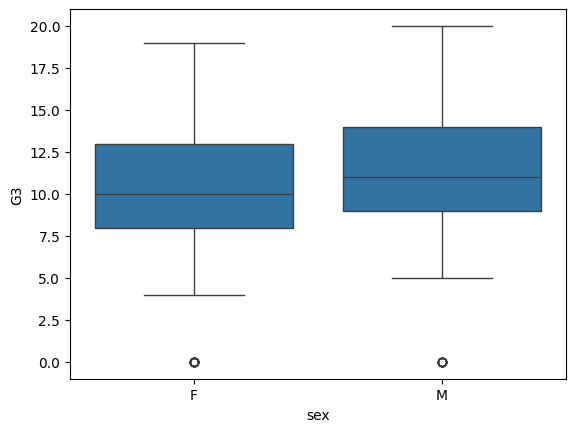

In [58]:

sns.boxplot(x="sex", y="G3" , data=math_df)

<Axes: xlabel='studytime', ylabel='G3'>

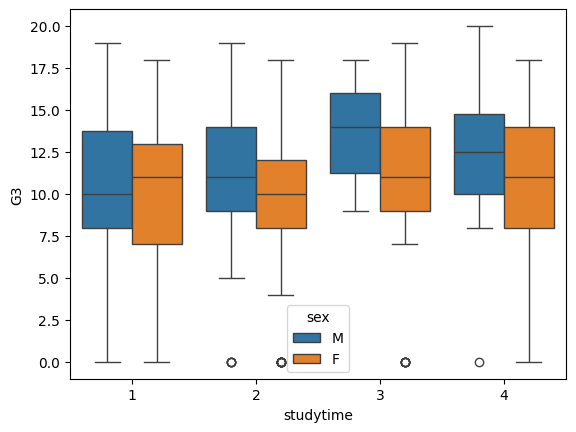

In [52]:
sns.boxplot(x="studytime", y="G3", hue="sex", data=math_df)

In [61]:
# t-test on studytime and G3 for male and female students
import scipy.stats as stats
male_group = math_df[math_df['sex'] == 'M']['G3']
female_group = math_df[math_df['sex'] == 'F']['G3']
t_stat, p_value = stats.ttest_ind(male_group, female_group)
print(f"t-statistic: {t_stat}, p-value: {p_value}")

if p_value < 0.05:
    print("Reject H0: There is a statistically significant difference in G3 between male and female students.")
else:
    print("Fail to reject H0: There is insufficient evidence of a difference in G3 between male and female students.")

t-statistic: 2.061992815503971, p-value: 0.039865332341527636
Reject H0: There is a statistically significant difference in G3 between male and female students.


Is absenteeism related to final grades? absences, G3 - Scatter - Pearson/Spearman